In [1]:
%matplotlib inline
import numpy as np
import torch
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

def use_svg_display():
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):
    """设置matplotlib图标大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, 
            xlim=None, ylim=None, xscale='linear', yscale='linear', 
            fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5,2.5),
            axes=None):
    """绘制数据"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else plt.gca()

    # 如果X有一个轴，输出True
    # hasattr(object, name, /)
    # 该实参是一个对象和一个字符串。如果字符串是对象的属性之一的名称，则返回 True，
    def has_one_axis(X): # 判断是不是一个一维列表
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                    and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

In [2]:
def f(x):
    return 3 * x ** 2 - 4 * x

def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


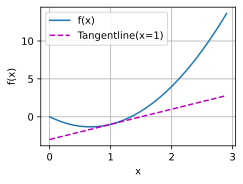

In [8]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x -3], 'x', 'f(x)', legend=['f(x)', 'Tangentline(x=1)'])

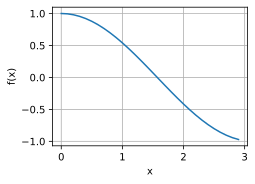

In [13]:
fig, ax = plt.subplots()
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
import numpy
ax.grid()
ax.plot(x, numpy.cos(x))
plt.show()